<a href="https://colab.research.google.com/github/apranav22/bayesian_nmor/blob/main/toy_bayesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

True B value = -0.028346854698761748


Text(0, 0.5, 'Measured alpha')

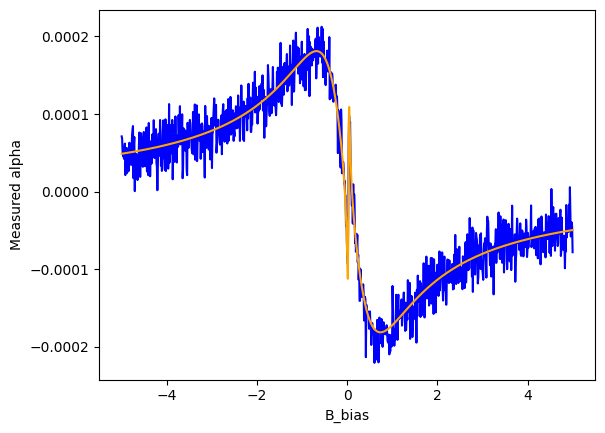

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
import sys
from scipy.stats import norm
from scipy.integrate import simpson
global tou, delta, k2, transit_rate, lo

# spontaneous emission rate ~ 10^7 Hz
tou = 10**7
# detuning
delta = 0.1 * tou
# saturation parameter
k2 = 5.0
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 0.001

folder_path = r"C:\Users\Dinesh\UGP"
sys.path.insert(0, folder_path)

def alpha_th(B_tot):
    # gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 1e7
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
    )
    return lo * alpha_th


def alpha_exp(alpha_th, sigma):
    return (alpha_th + np.random.normal(0, sigma, size=alpha_th.shape))

B_unk = np.random.uniform(-1, 1) #B_unknown can be anything between -2 and 2
print("True B value =", B_unk)
gamma = 0.02
sigma = 2e-5 #FIXME: This is not a percentage but an absolute value

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)


alpha_exp_vals = alpha_exp(alpha_vals, sigma)
plt.figure()
plt.plot(B_bias, alpha_exp_vals, color="blue")
plt.plot(B_bias, alpha_vals, color="orange")
plt.xlabel("B_bias")
plt.ylabel("Measured alpha")

Frequentist Scheme:

1.   An experiment corresponds to a fixed Bias and measuring Alpha as a signal against time. We then obtain an averaged Alpha for the same.
2.   We then do a field scan, an dobtain a graph of alpha against Bias (which by itself is costly because we ARE PHYSICALLY doing those many experiment)
3. then we  simple fir the model that minimises least square loss

-0.04180025387538736 +- 0.015478604775871001 is the estimated value of B_unk, and the true value is -0.028346854698761748


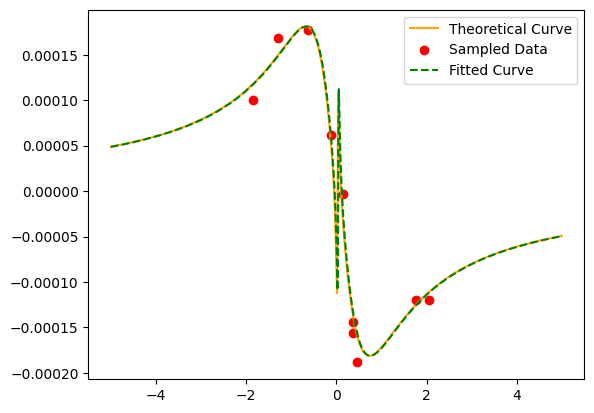

In [6]:
def MLE(B_unk, B_bias,  sigma = 2e-5):    
    B_tot = B_unk + B_bias
    alpha_vals = alpha_th(B_tot)
    alpha_exp_vals = alpha_exp(alpha_vals, sigma)
    num_samples = 10
    samples = np.random.uniform(B_bias.size//4, 3*B_bias.size//4, num_samples) #generates 10 random numbers for 10 sample indices from entire range of B_bias
    samples = np.round(samples).astype(int)
    B_bias_samples = B_bias[samples]
    alpha_vals_exp_samples = alpha_exp_vals[samples]
    plt.plot(B_bias, alpha_vals, label="Theoretical Curve", color="orange")
    plt.scatter(B_bias_samples, alpha_vals_exp_samples, label="Sampled Data", color="red")
    from scipy.optimize import curve_fit
    def alpha_model(B_total, B_unk_fit):
        B_tot_fit = B_unk_fit + B_total
        return alpha_th(B_tot_fit)
    initial_guess = [0.0, ]
    popt, pcov = curve_fit(
        alpha_model,
        B_bias_samples,
        alpha_vals_exp_samples,
        p0=initial_guess,
    )
    B_est_MLE = popt[0]
    print(popt[0], '+-', pcov[0][0]**0.5,  'is the estimated value of B_unk, and the true value is', B_unk)
    plt.plot(B_bias, alpha_model(B_bias, *popt), color="green", linestyle="--", label="Fitted Curve")
    plt.legend()
    return popt[0], pcov[0][0]**0.5

Mean, StdDev = MLE(B_unk, B_bias, sigma)

Bayesian Code Begins here

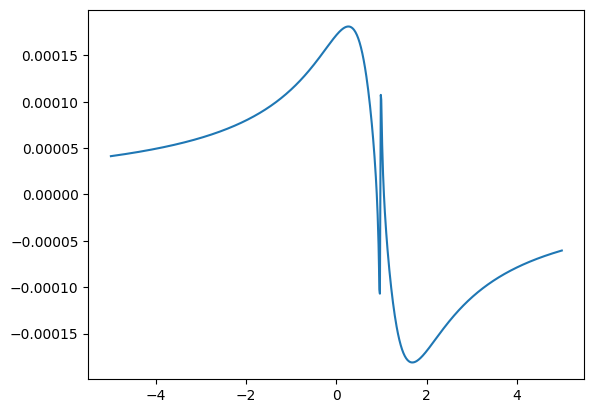

In [17]:
def alpha_theory(B_tot):
    return alpha_th(B_tot)

plt.plot(B_bias,alpha_theory(B_tot), label='alpha_theory')

# likelihood for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp)**2) / (2 * sigma**2)

    return prefactor * cp.exp(exponent)

def simpson_gpu(y, x):
    dx = x[1] - x[0]
    n = len(x)
    if n % 2 == 0:
        x = x[:-1]
        y = y[..., :-1]

    # Simpson's 1/3 rule: dx/3 * (y_0 + 4y_1 + 2y_2 + ... + 4y_{n-1} + y_n)
    return dx / 3. * cp.sum(y[..., 0:-1:2] + 4.*y[..., 1::2] + y[..., 2::2], axis=-1)


# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        # FASTER: Calculate likelihood for all B_grid points at once
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L

    # normalize
    post_sum = simpson_gpu(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        # Handle cases where the posterior is effectively zero everywhere
        post = cp.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post

# KL Divergence Utility
def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=10**3):
    # Sample possible outcomes (FIXME: this range is still hardcoded)
    alphas = cp.linspace(-0.1, 0.1, n_samples)

    # Shape: (n_samples, n_grid)
    alpha_grid, B_grid_2d = cp.meshgrid(alphas, B_grid, indexing='ij')
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)

    # Calculate marginal likelihood P(alpha|B_bias) for all alphas at once
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson_gpu(integrand_P_alpha, B_grid)

    # Calculate KL divergence for each alpha
    # The posterior for each alpha is integrand_P_alpha
    norm_factors = P_alpha


    epsilon = 1e-15
    # To avoid division by zero for alphas with zero probability
    valid_indices = norm_factors>0
    if not cp.any(valid_indices):
        return 0.0

    post_matrix = integrand_P_alpha[valid_indices] / norm_factors[valid_indices, cp.newaxis] #what does np.newaxis? FIXME

    ratio = post_matrix / (prior[cp.newaxis, :] + epsilon)
    ratio[ratio <= 0] = epsilon
    log_ratio = cp.log(ratio)

    # Handle -inf * 0 cases
    KL_integrand = post_matrix * log_ratio
    KL_integrand[cp.isnan(KL_integrand)] = 0.0
    KL_vals = simpson_gpu(KL_integrand, B_grid)

    P_alpha_sum = cp.sum(P_alpha[valid_indices])
    if P_alpha_sum == 0:
        return 0.0  # Return 0 if total probability is 0
        
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / P_alpha_sum

    # Calculate the final expected value
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / cp.sum(P_alpha[valid_indices])


    return float(expected_KL_val)


# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5, B_true=0.2, sigma=0.05, B_range=(-1, 1), n_grid=1000, candidates = cp.linspace(-1, 1, 5000), Test = 0, Gamma = 1.0
):  # FIXME: Why is b_range (-1,1)?

    # Step 1: initialize prior
    B_grid = cp.linspace(B_range[0], B_range[1], n_grid)
    prior = cp.ones_like(B_grid) / (B_range[1] - B_range[0])  # uniform prior
    B_biases = []
    Expected_KL =  []
    Mean, Mode, StdDev = [],[],[]
    posteriors = [prior]

    for _ in range(N_exp):
        # Step 2: choose bias by maximizing expected KL # FIXME
         # FIXME range of candidates is arbitrary
        util_vals = cp.array([expected_KL(b, prior, B_grid, sigma) for b in candidates])
        B_bias = candidates[cp.argmax(util_vals)]
        B_biases.append(B_bias)
        Expected_KL.append(float(cp.max(util_vals)))
      
        #code block which creates and saves plots of expected KL vs B_bias for each experiment within directory "Experiment i" - need to do the cp to np conversion
        #to use matplotlib ig - FIXME
        new_dir = "Tests/Test_{Test}".format(Test=Test)
        os.makedirs(new_dir, exist_ok=True)
        save_path = os.path.join(new_dir, f'Expected_KL_vs_B_bias_Experment{_+1}.png')
        plt.figure(figsize=(6, 4))
        plt.plot(candidates.get(), util_vals.get(), label="Expected KL divergence as a function of B_Bias")
        plt.xlabel("B_bias")
        plt.ylabel("Expected KL Divergence")
        plt.title("Expected KL vs B_bias for Experiment {i}".format(i=_+1))
        plt.savefig(save_path)


        # Step 3: generate synthetic measurement
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = cp.random.normal(alpha_true, sigma, size=5)  # 5 samples -> Integration time FIXME
        # Step 4: update posterior
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        posteriors.append(posterior)
        mean, mode, stddev = calculate_summary_stats(posterior.get(), B_grid.get())
        Mean += [mean]
        Mode += [mode]
        StdDev += [stddev]    
        prior = posterior
    final_posteriors_cpu = [p.get() for p in posteriors]
    final_biases_cpu = B_biases#.get()
    final_B_grid = B_grid.get()

    return final_B_grid, final_posteriors_cpu, final_biases_cpu, Expected_KL, Mean, Mode, StdDev

def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = simpson(B_grid * posterior, B_grid)

    # Mode
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]

     # Variance
    variance = simpson(((B_grid - mean)**2) * posterior, B_grid)

    return mean, mode, variance**0.5

Test 0

Final posterior area (should be ~1): 1.000000


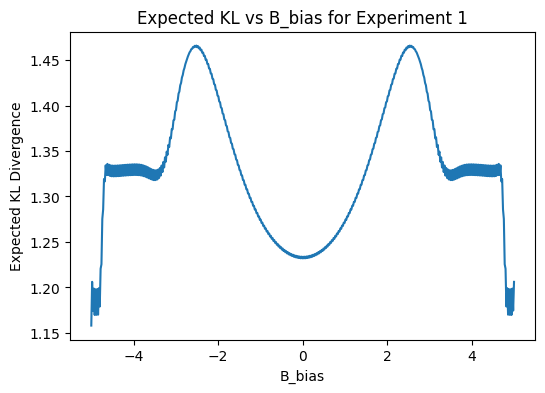

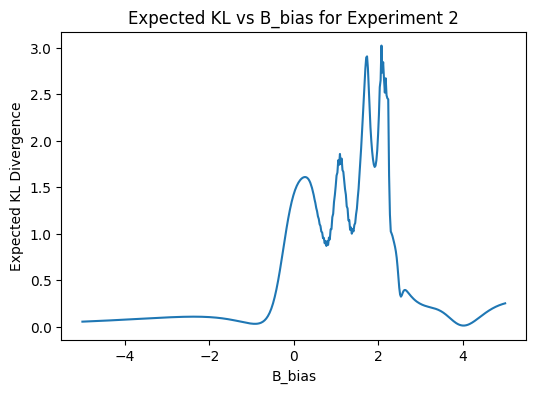

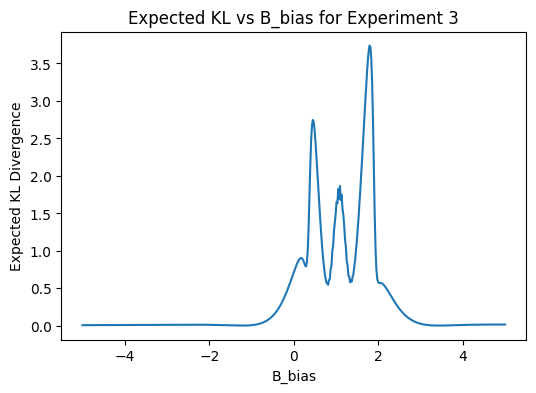

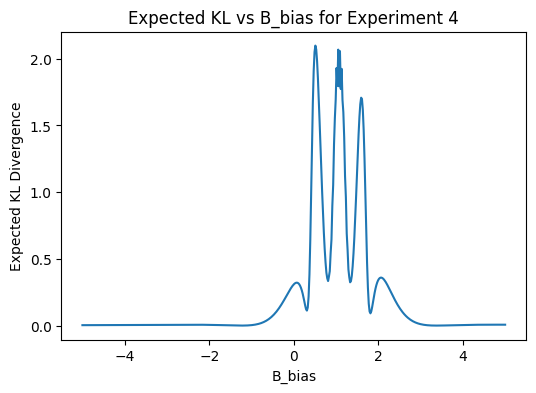

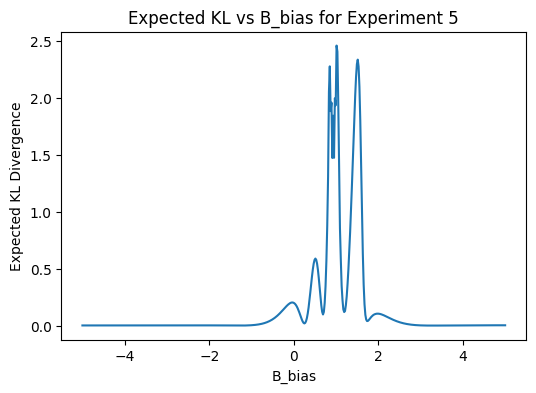

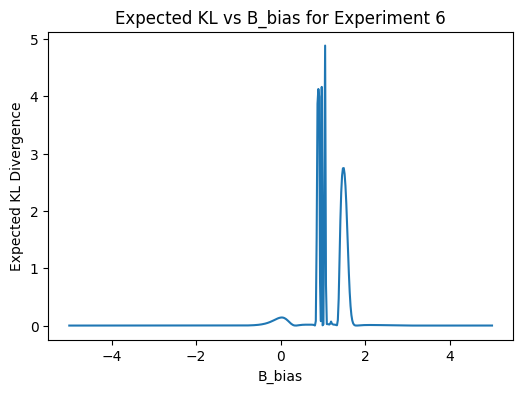

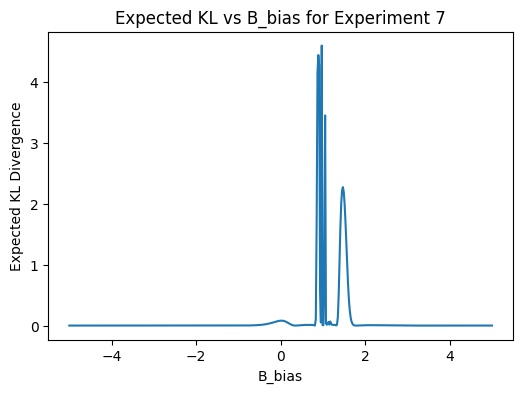

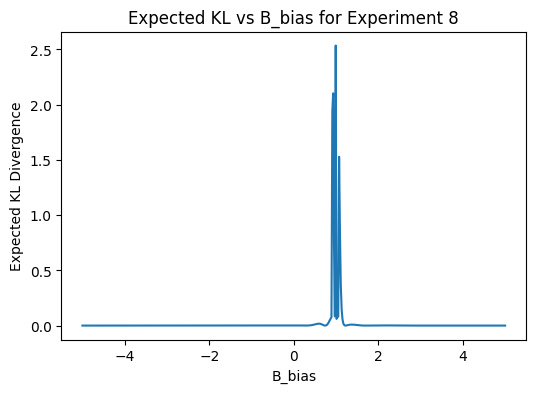

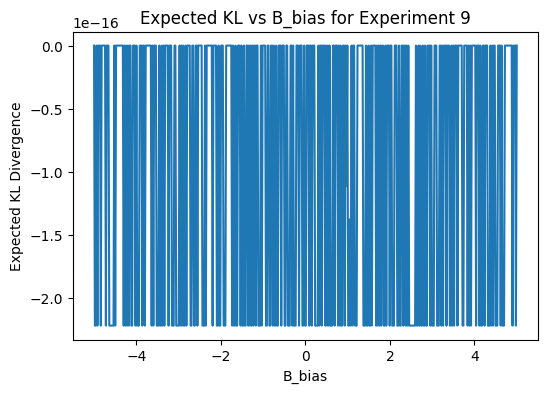

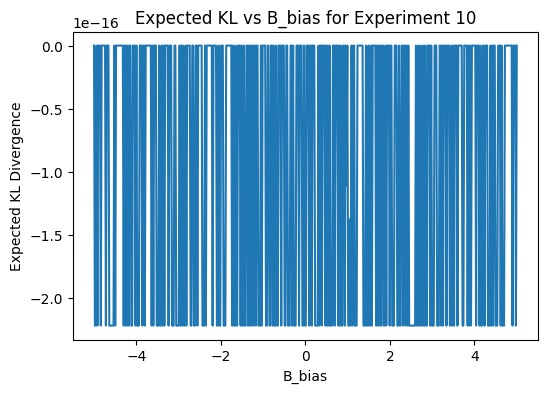

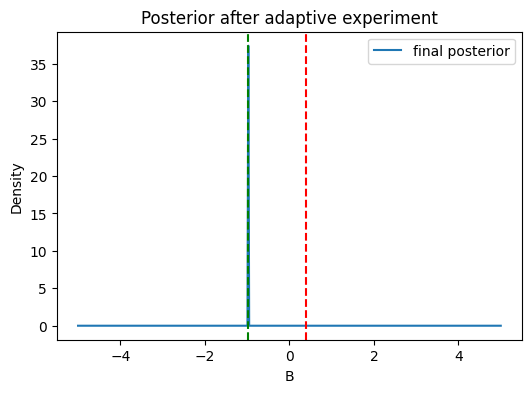

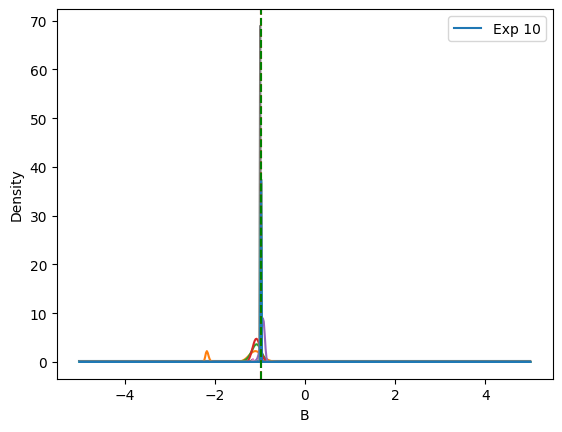

Mean: -0.9719438877755404 , Mode: -0.9719438877755513 , StdDev: 1.0880185641326473e-14
2.5350701402805607 : 1.465948619594434 

2.074148296593186 : 3.022210524932939 

1.793587174348697 : 3.7391134908046 

0.5110220440881761 : 2.099087733839779 

1.0120240480961922 : 2.460002418812996 

1.0521042084168335 : 4.882829963820226 

0.9719438877755509 : 4.599842375243174 

0.9919839679358715 : 2.5344381154821907 

0.911823647294589 : -8.554033983075458e-42 

0.911823647294589 : -5.640512493802226e-43 



In [ ]:
B_grid, posteriors, biases, xpected_kl, mean, mode, stddev = run_experiment(
    N_exp=10,
    B_true=B_unk,
    sigma=2e-5,
    B_range=(-5, 5),
    n_grid=500,
    candidates=cp.linspace(-5, 5, 500),
    Test=0,
    Gamma=0.01,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

print("Mean:", mean[-1], ", Mode:", mode[-1], ", StdDev:", stddev[-1])
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 1

In [18]:


B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=50,
    B_true=B_true,
    sigma=0.2,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=1,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

OverflowError: int too big to convert

Test 3

In [9]:

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    sigma=0,
    B_range=(-5, 5),
    n_grid=5000,
    candidates=cp.linspace(-5, 5, 5000),
    Test=3,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

OverflowError: int too big to convert

Test 4

In [ ]:

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    sigma=0.1,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=4,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

OverflowError: int too big to convert

Test 5

In [ ]:


B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=5000,
    candidates=cp.linspace(-1, 1, 5000),
    Test=5,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

ValueError: too many values to unpack (expected 3)

  Test 6

In [ ]:

B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=6,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

In [ ]:
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both

# TODO
# 2. interpretability
# 3. adaptive simpson
# 4. mcmc
# 5. float64->float32
# 6. adaptive grid refinememtn
# 7. vectorisation of likelihood 
